# Deep Learning: Attention Mechanisms & Temporal Fusion Transformers (TFT)

This notebook introduces State-of-the-Art (SOTA) time-series forecasting using the **Temporal Fusion Transformer (TFT)**. Unlike basic LSTMs or GRUs, the TFT uses attention mechanisms to provide high accuracy while maintaining interpretability. 

**Key advantages of TFT used in this notebook:**
1. **Heterogeneous Features:** It seamlessly integrates static covariates (e.g., `asset_class`), time-varying known inputs (e.g., `day_of_week`), and time-varying unknown inputs (e.g., `log_return`).
2. **Interpretability:** It outputs attention weights, allowing us to see *which* features actually drove the prediction.
3. **Quantile Predictions:** Instead of a single point forecast, it outputs confidence intervals via Quantile Loss.

We will use `pytorch_forecasting` and `lightning.pytorch` to streamline this complex architecture.

In [8]:
# Standard libraries
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch and PyTorch Lightning
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

# PyTorch Forecasting
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data import GroupNormalizer

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

### Data Preprocessing for PyTorch Forecasting

The `pytorch_forecasting` library has strict requirements for data formatting:
* It requires a continuous integer column representing time (`time_idx`) that increments by exactly 1 for each time step within each group.
* Target and continuous features must be strictly cast as `float`.
* Categorical features (both static and time-varying) must be cast as `str`.

In [2]:
# Define paths for inputs and outputs
DATA_PATH = '../data/quantitative_market_dataset.csv'
MODELS_DIR = '../models/'

# Ensure models directory exists
os.makedirs(MODELS_DIR, exist_ok=True)

print("Loading dataset...")
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])

# Drop rows with NaNs just in case
df = df.dropna().reset_index(drop=True)

# PyTorch Forecasting requires an integer time index ('time_idx')
# It must increment by exactly 1 for each timestep per group
df = df.sort_values(by=['ticker', 'Date'])
df['time_idx'] = df.groupby('ticker').cumcount()

# Ensure target and numerical features are floats
df['historical_volatility_20d'] = df['historical_volatility_20d'].astype(float)
df['log_return'] = df['log_return'].astype(float)
df['Volume'] = df['Volume'].astype(float)

# TFT can use known future information (like day of the week or month)
# Let's extract some calendar features and cast them as strings (categoricals)
df['day_of_week'] = df['Date'].dt.dayofweek.astype(str)
df['month'] = df['Date'].dt.month.astype(str)
df['asset_class'] = df['asset_class'].astype(str)

print(f"Dataset shape: {df.shape}")
display(df[['Date', 'ticker', 'time_idx', 'historical_volatility_20d', 'asset_class']].head())

Loading dataset...
Dataset shape: (113406, 14)


,Date,ticker,time_idx,historical_volatility_20d,asset_class
11824,2003-10-27,AGG,0,0.058908,Fixed_Income
11842,2003-10-28,AGG,1,0.057564,Fixed_Income
11844,2003-10-29,AGG,2,0.059499,Fixed_Income
11856,2003-10-30,AGG,3,0.059341,Fixed_Income
11875,2003-10-31,AGG,4,0.053664,Fixed_Income


### TimeSeriesDataSet & Temporal Split

Instead of manually generating 3D sequences (like we did for LSTM/GRU), the `TimeSeriesDataSet` class handles sliding windows automatically based on our `group_ids` and `time_idx`. We must categorize our variables here so the network routes them to the correct internal modules (e.g., routing static variables to the static covariate encoders).

In [3]:
# TFT Parameters
MAX_ENCODER_LENGTH = 20 # Lookback window (t-20 to t)
MAX_PREDICTION_LENGTH = 1 # Predict 1 step ahead (t+1)

# Temporal Split Date
# We calculate a date that roughly splits the dataset 80/20
df_sorted_by_date = df.sort_values('Date').reset_index(drop=True)
split_idx = int(len(df_sorted_by_date) * 0.8)
split_date = df_sorted_by_date.loc[split_idx, 'Date']

# Define the training dataset natively
# pytorch_forecasting handles sequences automatically based on time_idx and group_ids
print("Building TimeSeriesDataSet...")
training = TimeSeriesDataSet(
    df[df['Date'] < split_date],
    time_idx="time_idx",
    target="historical_volatility_20d", # Predict volatility directly
    group_ids=["ticker"],
    min_encoder_length=MAX_ENCODER_LENGTH,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["asset_class"], # Static covariates! TFT superpower
    time_varying_known_categoricals=["day_of_week", "month"], # Calendar features
    time_varying_unknown_reals=["log_return", "Volume", "historical_volatility_20d"],
    target_normalizer=GroupNormalizer(
        groups=["ticker"], transformation="softplus"
    ), # Normalizes the target per ticker
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Create validation dataset using the same parameters as training
# predict=True means we only get the last prediction for each time series
validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

# Create DataLoaders
BATCH_SIZE = 64
train_dataloader = training.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=BATCH_SIZE * 2, num_workers=0)

print("DataLoaders ready.")

Building TimeSeriesDataSet...
DataLoaders ready.


### Architecture Definition & Trainer Setup

We leverage `PyTorch Lightning` to handle the training loop, hardware allocation, and callbacks. We define callbacks for **Early Stopping** (to prevent overfitting) and **Model Checkpointing** (to automatically save the weights that achieve the lowest validation loss).

In [4]:
# Early stopping callback to prevent the overfitting we saw in LSTM/GRU
early_stop_callback = EarlyStopping(
    monitor="val_loss", 
    min_delta=1e-4, 
    patience=5, 
    verbose=True, 
    mode="min"
)

# Checkpoint callback to save the best model weights
checkpoint_callback = ModelCheckpoint(
    dirpath=MODELS_DIR,
    filename="tft_volatility",
    monitor="val_loss",
    mode="min",
    save_top_k=1
)

# Setup PyTorch Lightning Trainer
trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto", # Uses GPU if available, else CPU
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback, checkpoint_callback],
    # limit_train_batches=50, # NOTE: Remove this limit in the final run to train on full dataset!
)

# Define the TFT model architecture
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(), # TFT optimizes for quantiles by default, giving confidence intervals
    log_interval=10,
    optimizer="adam",
    reduce_on_plateau_patience=4,
)

print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 19.4k


In [5]:
print("Starting TFT Training...")
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

Starting TFT Training...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    131 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    112 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    783 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 19.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 299                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.012
Metric val_loss improved by 0.002 >= min_delta = 0.0001. New best score: 0.010
Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.010
Metric val_loss improved by 0.001 >= min_delta = 0.0001. New best score: 0.009
Monitored metric val_loss did not improve in the last 5 records. Best score: 0.009. Signaling Trainer to stop.


### Evaluation & Quantile Parsing

Because the TFT optimizes `QuantileLoss`, its raw output contains predictions for 7 different quantiles (e.g., 2nd, 10th, 25th, 50th, 75th, 90th, 98th percentiles). To evaluate standard metrics (RMSE, MAE), we extract the median prediction (the 50th percentile, located at index `3`).

In [6]:
# Load the best model from checkpoint
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

print(f"Loaded best model from: {best_model_path}")

# Get point predictions directly (TFT automatically picks the median quantile)
predictions = best_tft.predict(val_dataloader).cpu().numpy()

# Extract actual unscaled targets natively from the dataloader 
targets = torch.cat([y[0] for x, y in val_dataloader]).cpu().numpy()

# Flatten arrays to ensure they are 1D vectors for scikit-learn
preds_median = predictions.flatten()
targets = targets.flatten()

# Calculate metrics
rmse = np.sqrt(mean_squared_error(targets, preds_median))
mae = mean_absolute_error(targets, preds_median)
r2 = r2_score(targets, preds_median)

print("\n--- Final Evaluation on Validation Set ---")
print(f"TFT Test RMSE: {rmse:.5f}")
print(f"TFT Test MAE: {mae:.5f}")
print(f"TFT Test R2: {r2:.5f}")

results_tft = pd.DataFrame({
    'Model': ['TFT'],
    'Test_RMSE': [rmse],
    'Test_MAE': [mae],
    'Test_R2': [r2]
}).set_index('Model')

display(results_tft)

Loaded best model from: C:\Users\frang\Desktop\dream_tfm\models\tft_volatility-v2.ckpt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



--- Final Evaluation on Validation Set ---
TFT Test RMSE: 0.02942
TFT Test MAE: 0.01552
TFT Test R2: 0.97371


,Test_RMSE,Test_MAE,Test_R2
Model,,,
TFT,0.029423,0.01552,0.973709


### Model Interpretability

The greatest advantage of the Temporal Fusion Transformer over standard Black-Box Deep Learning is its interpretability. By analyzing the variable selection networks within the TFT, we can plot exactly which variables the model deemed most important for making its volatility predictions.

In [9]:
# Get raw predictions and calculate the interpretation
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)[0]
interpretation = best_tft.interpret_output(raw_predictions, reduction="mean")

# Extract feature names from the model
static_vars = best_tft.static_variables
encoder_vars = best_tft.encoder_variables

# Extract importance values and ensure they are 1D arrays
static_imp = interpretation['static_variables'].cpu().numpy()
encoder_imp = interpretation['encoder_variables'].cpu().numpy()

if static_imp.ndim > 1:
    static_imp = static_imp.mean(axis=0)
if encoder_imp.ndim > 1:
    encoder_imp = encoder_imp.mean(axis=0)

# Normalize to sum up to 100%
static_imp = (static_imp / static_imp.sum()) * 100
encoder_imp = (encoder_imp / encoder_imp.sum()) * 100

# Sort indices for descending plot order
static_idx = np.argsort(static_imp)[::-1]
encoder_idx = np.argsort(encoder_imp)[::-1]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


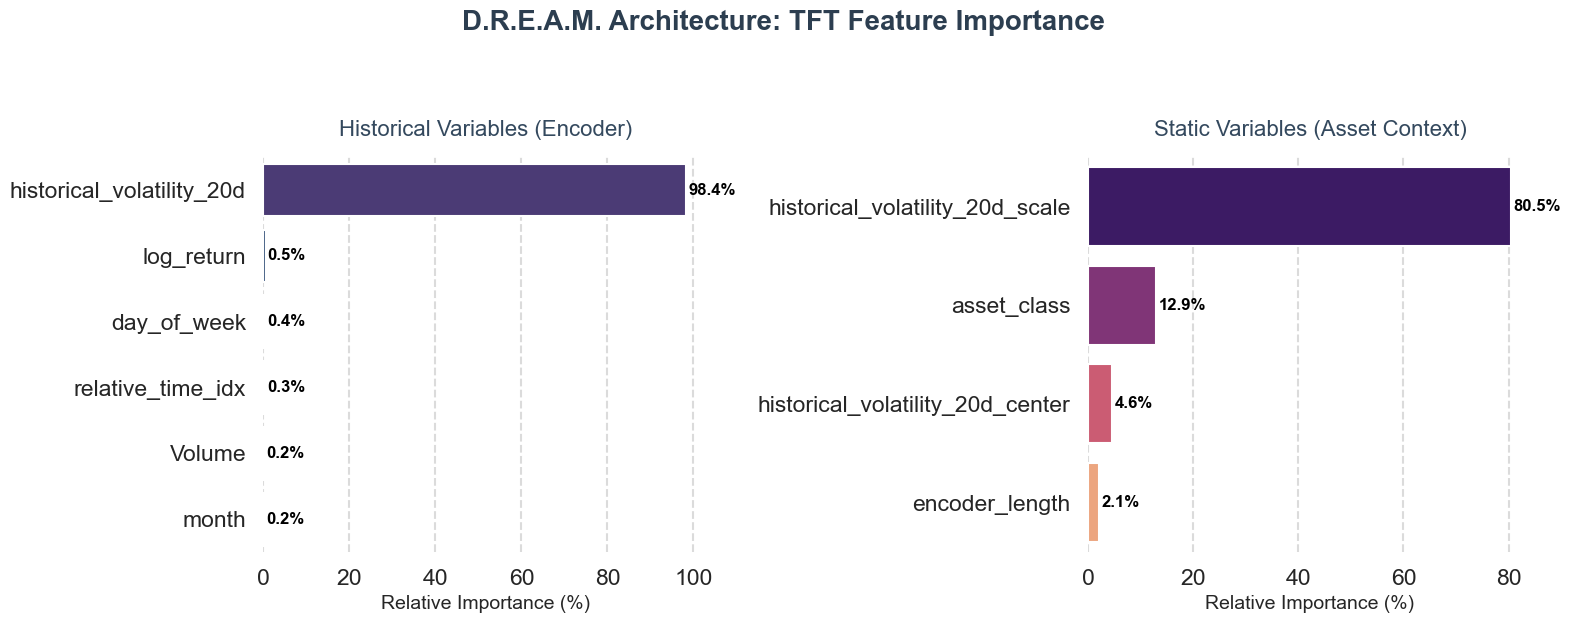

In [10]:
# Plotting
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("D.R.E.A.M. Architecture: TFT Feature Importance", 
             fontsize=20, fontweight='bold', y=1.05, color='#2c3e50')

# Subplot 1: Encoder Variables (Time-varying past inputs)
sns.barplot(
    x=encoder_imp[encoder_idx], 
    y=np.array(encoder_vars)[encoder_idx], 
    ax=axes[0], 
    palette="viridis",
    orient='h'
)
axes[0].set_title("Historical Variables (Encoder)", fontsize=16, pad=15, color='#34495e')
axes[0].set_xlabel("Relative Importance (%)", fontsize=14)
axes[0].set_ylabel("")

# Add percentage labels to bars
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%', 
                     (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=12, color='black', fontweight='bold')

# Subplot 2: Static Variables (Asset Class)
sns.barplot(
    x=static_imp[static_idx], 
    y=np.array(static_vars)[static_idx], 
    ax=axes[1], 
    palette="magma",
    orient='h'
)
axes[1].set_title("Static Variables (Asset Context)", fontsize=16, pad=15, color='#34495e')
axes[1].set_xlabel("Relative Importance (%)", fontsize=14)
axes[1].set_ylabel("")

# Add percentage labels to bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.1f}%', 
                     (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=12, color='black', fontweight='bold')

# Clean up axes for a modern look
sns.despine(left=True, bottom=True)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].xaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()